# 01c — Review ảnh negative nghi ngờ (`tomato_leaf_disease_v1`)

**Bối cảnh:** `03_train_leaf_baseline.ipynb` cho thấy 24,6% ảnh negative (lá khỏe) trong `test` bị model báo nhầm có bệnh, và **toàn bộ** báo nhầm đều là `leaf_mold`. Kiểm tra ảnh audit ở `01_build_tomato_leaf_disease_v1.ipynb` cũng từng phát hiện 1 ảnh negative có tên gốc `Leaf-Mold-514...jpg` — nghi ngờ một số ảnh `Healthy` trong dữ liệu gốc thực ra có dấu hiệu bệnh nhưng bị annotator gắn nhãn sai (Roboflow gắn nhãn theo từng vùng/lá riêng lẻ trong ảnh nhiều lá).

**Mục tiêu notebook này:** thu hẹp ~589 ảnh negative của toàn dataset xuống còn 1 shortlist nhỏ đáng ngờ nhất, để bạn xác nhận bằng mắt lần cuối — thay vì rà thủ công toàn bộ. Notebook này **không sửa dataset**, chỉ sinh ra `review_candidates_negative.csv` + ảnh lưới để tham khảo cho lần build dataset kế tiếp.

## Cách lọc (2 lớp, kết hợp lại)
1. **Lọc theo tên file gốc**: ảnh negative có tên file gốc (trước khi bị Roboflow gắn `.rf.<hash>`) chứa từ khóa của 1 trong 6 bệnh/tình trạng ngoài phạm vi MVP (`bacterial spot`, `iron deficiency`, `leaf miner`, `mosaic virus`, `spider mites`, `yellow leaf curl virus`) hoặc từ khóa chung (`mold`, `blight`, `spot`, `virus`, `mite`, `curl`, `deficiency`).
2. **Lọc theo chính model đã train**: chạy `best.pt` của `03_train_leaf_baseline.ipynb` lên toàn bộ ảnh negative (train+val+test) — ảnh nào model tự tin báo có bệnh dù nhãn gốc Healthy thì đáng ngờ.

## Trước khi chạy
1. **Add Input** → 2 Kaggle Dataset:
   - Output đã Save Version của `01_build_tomato_leaf_disease_v1.ipynb` (dataset `tomato_leaf_disease_v1`).
   - Output đã Save Version của `03_train_leaf_baseline.ipynb` (chứa `models/tomato_leaf_disease_yolov8n_baseline.pt`).
2. Accelerator: GPU giúp nhanh hơn nhưng không bắt buộc (chỉ predict, không train, ~589 ảnh).
3. Không cần Internet (không tải gì thêm ngoài `ultralytics` qua pip).

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "ultralytics"], check=False)

import re
from collections import defaultdict
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from PIL import Image

print("CUDA khả dụng:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 552.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s eta 0:00:00
CUDA khả dụng: True


### Bước 0 — Tự nhận diện dataset + model input
Không đoán đường dẫn — tìm `data.yaml` khớp 4 class, và tìm file model theo đúng tên đã đặt ở `03_train_leaf_baseline.ipynb`.

In [2]:
TARGET_CLASSES = ["leaf_early_blight", "leaf_late_blight", "leaf_mold", "leaf_septoria_spot"]


def find_dataset_root():
    for yf in Path("/kaggle/input").rglob("data.yaml"):
        try:
            y = yaml.safe_load(yf.read_text(encoding="utf-8"))
        except Exception:
            continue
        names = y.get("names") if isinstance(y, dict) else None
        if isinstance(names, dict):
            names = [names[k] for k in sorted(names)]
        if names == TARGET_CLASSES:
            return yf.parent
    return None


def find_model_path():
    hits = list(Path("/kaggle/input").rglob("tomato_leaf_disease_yolov8n_baseline.pt"))
    return hits[0] if hits else None


DATASET_ROOT = find_dataset_root()
MODEL_PATH = find_model_path()

if DATASET_ROOT is None:
    print("Các thư mục cấp 1 trong /kaggle/input:")
    for p in sorted(Path("/kaggle/input").glob("*")):
        print(" -", p)
    raise FileNotFoundError(
        "Không tìm thấy data.yaml khớp 4 class của tomato_leaf_disease_v1. "
        "Kiểm tra đã Add Input output của 01_build_tomato_leaf_disease_v1.ipynb chưa."
    )
if MODEL_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy tomato_leaf_disease_yolov8n_baseline.pt trong /kaggle/input. "
        "Kiểm tra đã Add Input output đã Save Version của 03_train_leaf_baseline.ipynb chưa "
        "(dataset đó phải chứa thư mục models/)."
    )

print("DATASET_ROOT:", DATASET_ROOT)
print("MODEL_PATH  :", MODEL_PATH)

DATASET_ROOT: /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1
MODEL_PATH  : /kaggle/input/notebooks/sonlest/03-train-leaf-baseline/models/tomato_leaf_disease_yolov8n_baseline.pt


### Bước 1 — Gom toàn bộ ảnh negative (train + val + test)

In [3]:
negative_records = []
for split in ["train", "val", "test"]:
    images_dir = DATASET_ROOT / split / "images"
    labels_dir = DATASET_ROOT / split / "labels"
    if not images_dir.exists():
        continue
    for img_path in sorted(images_dir.glob("*")):
        label_path = labels_dir / (img_path.stem + ".txt")
        lines = [l for l in label_path.read_text().splitlines() if l.strip()] if label_path.exists() else []
        if not lines:
            negative_records.append({"path": img_path, "split": split})

print(f"Tổng số ảnh negative (train+val+test): {len(negative_records)}")
print(pd.DataFrame(negative_records)["split"].value_counts())

Tổng số ảnh negative (train+val+test): 589
split
train    439
val       89
test      61
Name: count, dtype: int64


### Bước 2 — Lọc theo từ khóa trong tên file gốc
File trong dataset có tiền tố `leaf_roboflow__<tên_gốc>.rf.<hash>.<ext>` — bóc lại `<tên_gốc>` rồi so với danh sách từ khóa bệnh/tình trạng ngoài phạm vi MVP.

In [5]:
DISEASE_KEYWORDS = [
    "bacterial_spot", "iron_deficiency", "leaf_miner", "mosaic_virus",
    "spider_mite", "yellow_leaf_curl",
    "mold", "blight", "spot", "virus", "mite", "curl", "deficiency",
]


def normalize_name(s):
    return re.sub(r"[\s_-]+", "_", s.strip().lower())


def original_filename(img_path):
    """leaf_roboflow__<ten_goc>.rf.<hash>.<ext> -> <ten_goc>"""
    stem = img_path.stem
    stem = re.sub(r"^leaf_roboflow__", "", stem)
    stem = re.sub(r"\.rf\.[0-9a-fA-F]{16,}$", "", stem)
    return stem


def keyword_hits(img_path):
    norm = normalize_name(original_filename(img_path))
    return [kw for kw in DISEASE_KEYWORDS if kw in norm]


for rec in negative_records:
    hits = keyword_hits(rec["path"])
    rec["orig_filename"] = original_filename(rec["path"])
    rec["keyword_hits"] = ", ".join(hits)
    rec["keyword_flag"] = len(hits) > 0

n_keyword_flag = sum(r["keyword_flag"] for r in negative_records)
print(f"Ảnh negative bị nghi ngờ theo tên file: {n_keyword_flag} / {len(negative_records)}")
print(pd.DataFrame([r for r in negative_records if r["keyword_flag"]])[["orig_filename", "keyword_hits", "split"]]
      .head(20).to_string(index=False))

Ảnh negative bị nghi ngờ theo tên file: 62 / 589
       orig_filename keyword_hits split
Late-Blight-650-_jpg       blight train
Late-Blight-650-_jpg       blight train
Late-Blight-650-_jpg       blight train
Late-Blight-651-_JPG       blight train
Late-Blight-651-_JPG       blight train
Late-Blight-651-_JPG       blight train
Late-Blight-652-_JPG       blight train
Late-Blight-652-_JPG       blight train
Late-Blight-652-_JPG       blight train
Late-Blight-653-_JPG       blight train
Late-Blight-653-_JPG       blight train
Late-Blight-653-_JPG       blight train
Late-Blight-654-_JPG       blight train
  Leaf-Mold-509-_JPG         mold train
  Leaf-Mold-509-_JPG         mold train
  Leaf-Mold-509-_JPG         mold train
  Leaf-Mold-510-_JPG         mold train
  Leaf-Mold-510-_JPG         mold train
  Leaf-Mold-510-_JPG         mold train
  Leaf-Mold-512-_JPG         mold train


### Bước 3 — Lọc theo dự đoán của `best.pt`
Chạy model trên toàn bộ ảnh negative, ghi lại class + confidence cao nhất nếu có box được dự đoán (conf ≥ 0.25, ngưỡng đã dùng xuyên suốt các notebook trước).

In [6]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))

BATCH = 32
all_paths = [str(r["path"]) for r in negative_records]
model_flags = {}

for i in range(0, len(all_paths), BATCH):
    batch_paths = all_paths[i:i + BATCH]
    results = model.predict(source=batch_paths, imgsz=640, conf=0.25, verbose=False)
    for p, res in zip(batch_paths, results):
        if len(res.boxes) == 0:
            model_flags[p] = (False, None, 0.0)
            continue
        confs = res.boxes.conf.tolist()
        clss = res.boxes.cls.tolist()
        top_idx = max(range(len(confs)), key=lambda k: confs[k])
        model_flags[p] = (True, TARGET_CLASSES[int(clss[top_idx])], float(confs[top_idx]))
    print(f"  đã xử lý {min(i + BATCH, len(all_paths))}/{len(all_paths)} ảnh...")

for rec in negative_records:
    flag, cname, conf = model_flags[str(rec["path"])]
    rec["model_flag"] = flag
    rec["model_top_class"] = cname
    rec["model_top_conf"] = round(conf, 3)

n_model_flag = sum(r["model_flag"] for r in negative_records)
print(f"\nẢnh negative bị model tự báo có bệnh: {n_model_flag} / {len(negative_records)} "
      f"({100 * n_model_flag / len(negative_records):.1f}%)")
print(pd.DataFrame([r for r in negative_records if r["model_flag"]])["model_top_class"].value_counts())

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  đã xử lý 32/589 ảnh...
  đã xử lý 64/589 ảnh...
  đã xử lý 96/589 ảnh...
  đã xử lý 128/589 ảnh...
  đã xử lý 160/589 ảnh...
  đã xử lý 192/589 ảnh...
  đã xử lý 224/589 ảnh...
  đã xử lý 256/589 ảnh...
  đã xử lý 288/589 ảnh...
  đã xử lý 320/589 ảnh...
  đã xử lý 352/589 ảnh...
  đã xử lý 384/589 ảnh...
  đã xử lý 416/589 ảnh...
  đã xử lý 448/589 ảnh...
  đã xử lý 480/589 ảnh...
  đã xử lý 512/589 ảnh...
  đã xử lý 544/589 ảnh...
  đã xử lý 576/589 ảnh...
  đã xử lý 589/589 ảnh...

Ảnh negative bị model tự báo có bệnh: 88 / 589 (14.9%)
model_top_class
leaf_mold             59
leaf_late_blight      17
leaf_septoria_spot     7
leaf_early_blight      5
Name: count, dtype: int64


### Bước 4 — Gộp 2 lớp lọc, xếp hạng ưu tiên review

In [7]:
df = pd.DataFrame(negative_records)
df["path"] = df["path"].astype(str)


def priority(row):
    if row["keyword_flag"] and row["model_flag"]:
        return 2  # cả 2 lớp đều nghi ngờ -> ưu tiên cao nhất
    if row["model_flag"] or row["keyword_flag"]:
        return 1
    return 0


df["priority"] = df.apply(priority, axis=1)
df = df.sort_values(["priority", "model_top_conf"], ascending=[False, False])

candidates = df[df["priority"] > 0].copy()
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
candidates.to_csv(WORKING / "review_candidates_negative.csv", index=False)
df.to_csv(WORKING / "negative_images_full_scan.csv", index=False)

print(f"Tổng ảnh negative: {len(df)}")
print(f"  Nghi ngờ CẢ 2 lớp lọc (ưu tiên cao nhất): {(df['priority'] == 2).sum()}")
print(f"  Nghi ngờ 1 trong 2 lớp lọc              : {(df['priority'] == 1).sum()}")
print(f"  Không nghi ngờ gì (có thể vẫn giữ nguyên): {(df['priority'] == 0).sum()}")
print(f"\n-> Shortlist cần xem lại bằng mắt: {len(candidates)} / {len(df)} ảnh "
      f"({100 * len(candidates) / len(df):.1f}% thay vì phải xem hết 100%).")
print("\nĐã lưu:")
print(" -", WORKING / "review_candidates_negative.csv")
print(" -", WORKING / "negative_images_full_scan.csv")

print("\nTop 15 ảnh nghi ngờ nhất:")
print(candidates[["orig_filename", "split", "keyword_hits", "model_top_class", "model_top_conf"]]
      .head(15).to_string(index=False))

Tổng ảnh negative: 589
  Nghi ngờ CẢ 2 lớp lọc (ưu tiên cao nhất): 62
  Nghi ngờ 1 trong 2 lớp lọc              : 26
  Không nghi ngờ gì (có thể vẫn giữ nguyên): 501

-> Shortlist cần xem lại bằng mắt: 88 / 589 ảnh (14.9% thay vì phải xem hết 100%).

Đã lưu:
 - /kaggle/working/review_candidates_negative.csv
 - /kaggle/working/negative_images_full_scan.csv

Top 15 ảnh nghi ngờ nhất:
     orig_filename split keyword_hits model_top_class  model_top_conf
Leaf-Mold-511-_JPG   val         mold       leaf_mold           0.974
Leaf-Mold-512-_JPG train         mold       leaf_mold           0.969
Leaf-Mold-511-_JPG   val         mold       leaf_mold           0.969
Leaf-Mold-512-_JPG train         mold       leaf_mold           0.965
Leaf-Mold-514-_JPG train         mold       leaf_mold           0.961
Leaf-Mold-515-_JPG   val         mold       leaf_mold           0.961
Leaf-Mold-523-_JPG   val         mold       leaf_mold           0.961
Leaf-Mold-517-_JPG train         mold       leaf_mold  

### Bước 5 — Lưới ảnh để xem nhanh bằng mắt
Vẽ box dự đoán của model (nếu có) lên top ảnh nghi ngờ nhất, chia thành nhiều trang 12 ảnh/trang cho dễ nhìn.

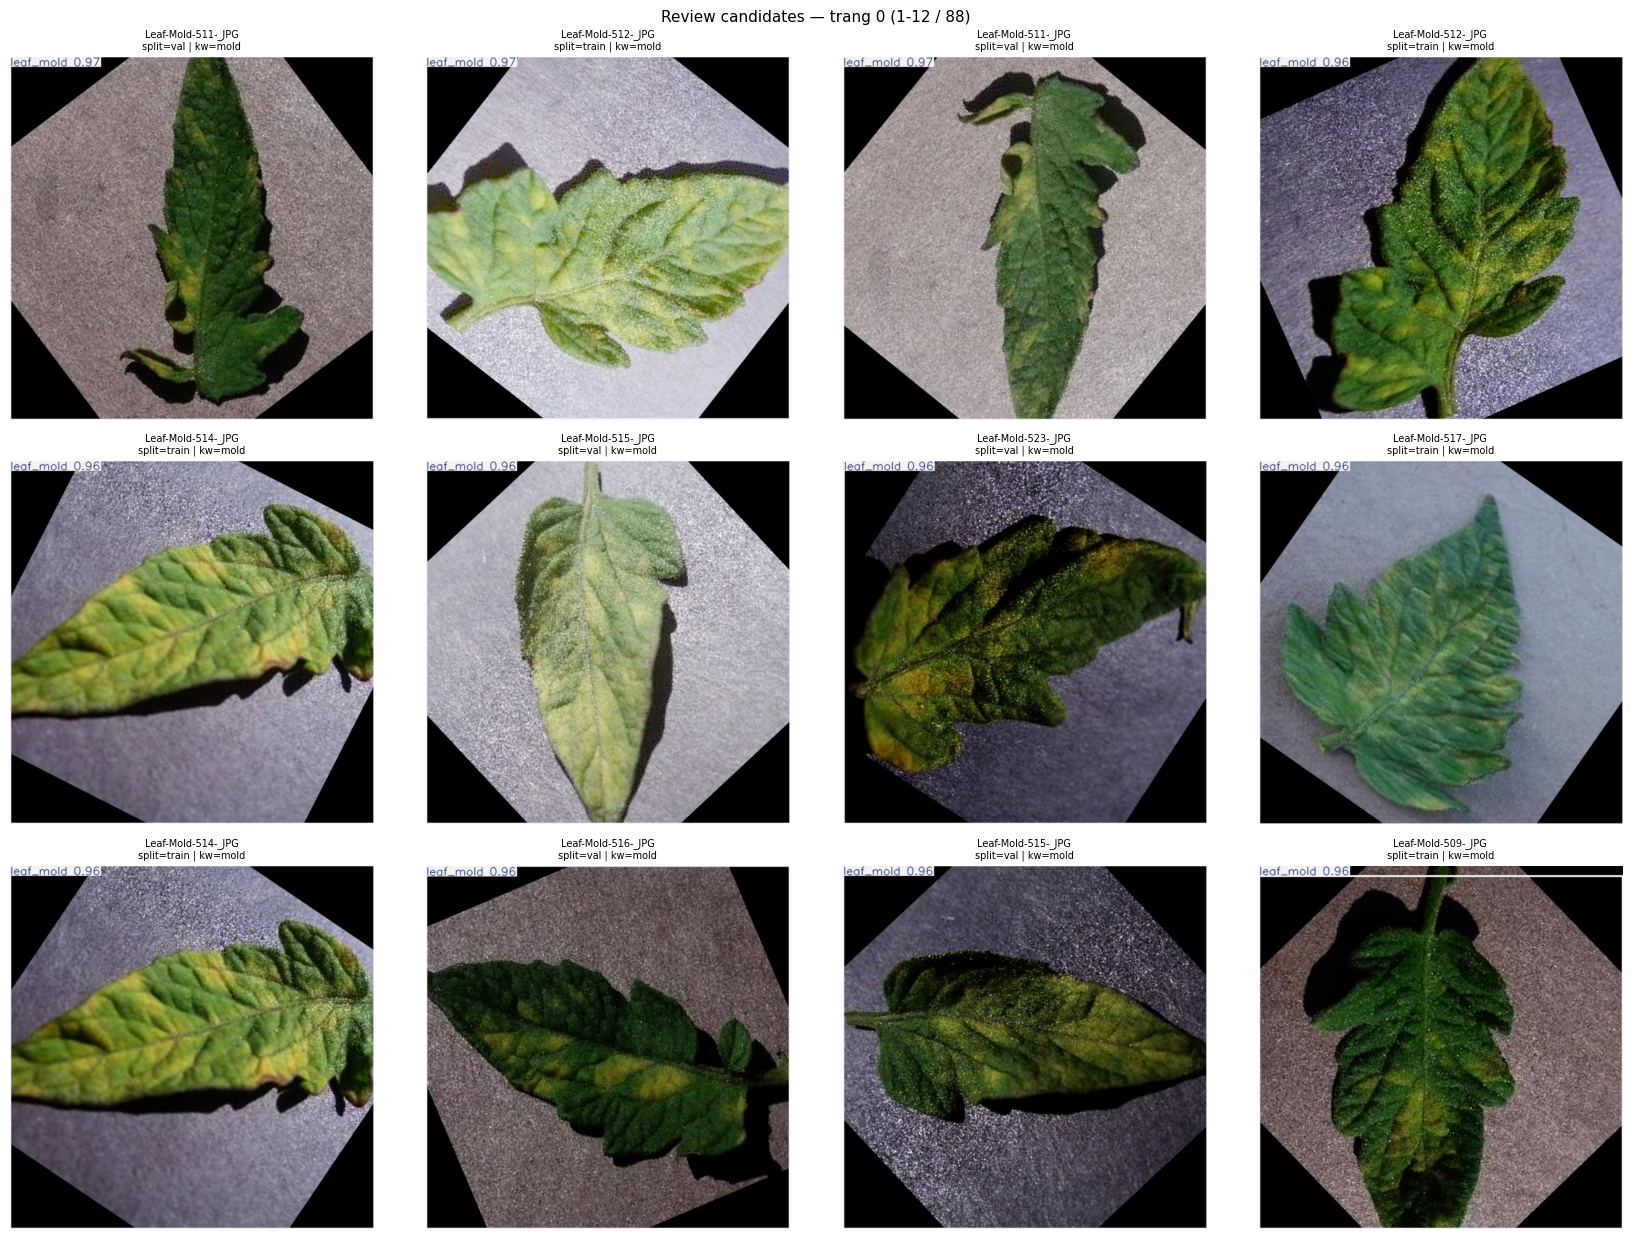

Đã lưu: /kaggle/working/review_grid_page0.png


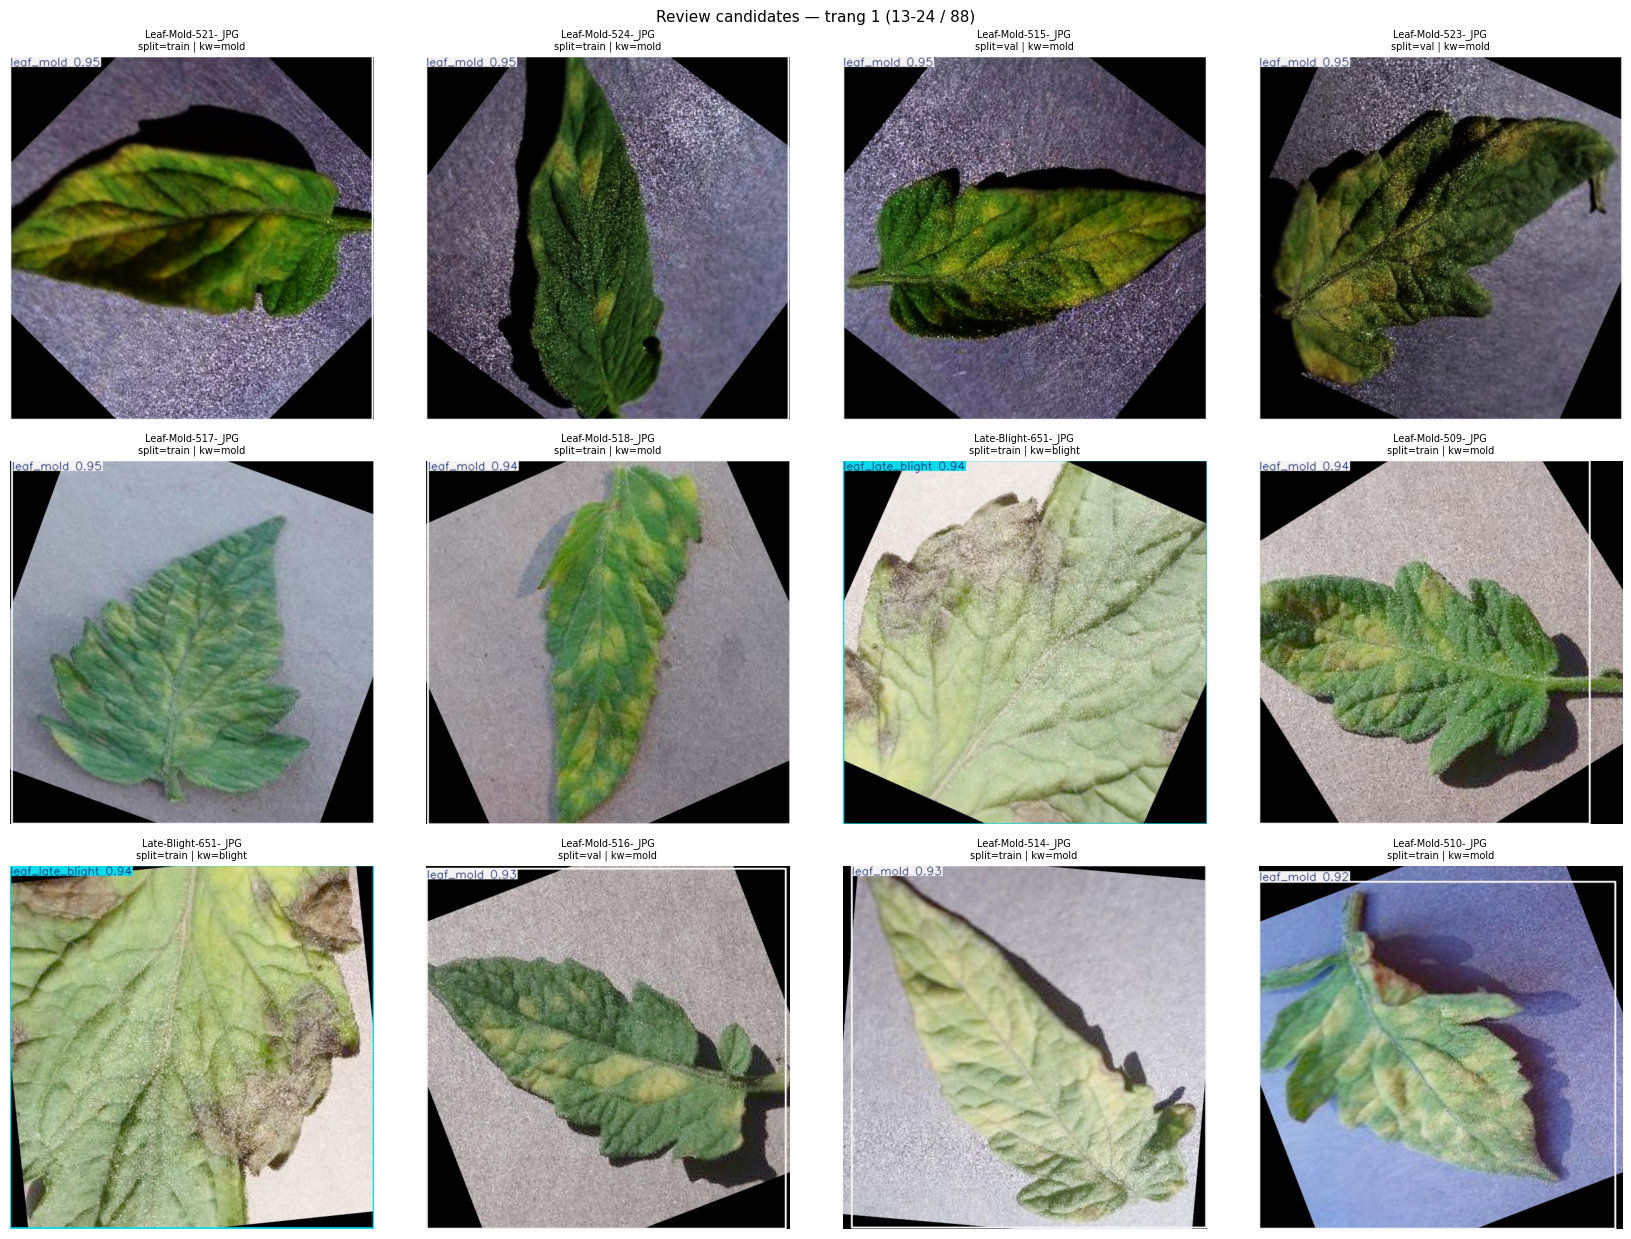

Đã lưu: /kaggle/working/review_grid_page1.png


In [8]:
def show_candidates_grid(cand_df, page=0, per_page=12, cols=4, conf=0.25):
    start = page * per_page
    chunk = cand_df.iloc[start:start + per_page]
    if chunk.empty:
        print(f"Không còn ảnh ở trang {page} (đã hết {len(cand_df)} ảnh candidates).")
        return

    rows = (len(chunk) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4.2 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    results = model.predict(source=chunk["path"].tolist(), imgsz=640, conf=conf, verbose=False)
    for ax, (_, row), res in zip(axes, chunk.iterrows(), results):
        annotated = res.plot()[:, :, ::-1]
        ax.imshow(annotated)
        ax.set_title(f"{row['orig_filename'][:30]}\nsplit={row['split']} | kw={row['keyword_hits']}",
                      fontsize=7)
        ax.axis("off")
    for ax in axes[len(chunk):]:
        ax.axis("off")

    fig.suptitle(f"Review candidates — trang {page} ({start + 1}-{start + len(chunk)} / {len(cand_df)})",
                 fontsize=11)
    plt.tight_layout()
    save_path = WORKING / f"review_grid_page{page}.png"
    plt.savefig(save_path, dpi=80, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Đã lưu:", save_path)


# Mặc định xem 2 trang đầu (24 ảnh nghi ngờ nhất). Đổi `page=2,3,...` để xem tiếp phần còn lại của
# review_candidates_negative.csv nếu muốn rà kỹ hơn.
show_candidates_grid(candidates, page=0)
show_candidates_grid(candidates, page=1)

## Kết quả
- `review_candidates_negative.csv` — shortlist ảnh negative đáng ngờ (đã sắp theo độ ưu tiên), kèm `orig_filename` để đối chiếu ngược lại nguồn Roboflow gốc nếu cần.
- `negative_images_full_scan.csv` — toàn bộ 589 ảnh negative kèm 2 cờ lọc, để tham khảo nếu muốn tự chỉnh ngưỡng.
- `review_grid_page0.png`, `review_grid_page1.png` — ảnh lưới đã xem trực quan.

## Cách dùng kết quả này (không tự động sửa dataset)
Notebook này **chỉ chẩn đoán, không sửa**. Sau khi bạn xác nhận bằng mắt danh sách candidates:
1. Ảnh nào thực sự có dấu hiệu bệnh (đặc biệt `leaf_mold`) → ghi lại `orig_filename`, để lần build dataset kế tiếp (`01_build_tomato_leaf_disease_v1.ipynb` phiên bản sau) loại các ảnh này khỏi tập negative (chuyển sang `rejected_images.csv` hoặc gắn lại nhãn đúng nếu review được cả vị trí bệnh).
2. Ảnh nào model báo nhầm nhưng thực sự là lá khỏe (model quá nhạy) → không cần sửa dataset, chỉ là hạn chế của baseline hiện tại — có thể cải thiện bằng cách tăng đa dạng ảnh negative khi train lại.
3. Ghi số liệu review vào `manifests/dataset_report.md` của lần build kế tiếp để có evidence trace được, đúng tinh thần "báo cáo trung thực" của tài liệu dự án.

## Lưu ý
- Model dùng để lọc (`03_train_leaf_baseline.ipynb`) **chính là model học từ dữ liệu có thể chứa nhãn nhiễu này** — nên nó có thể vừa đúng (phát hiện đúng nhãn sai) vừa lặp lại thiên kiến của chính nó (quá nhạy với `leaf_mold` do đã học từ nhãn nhiễu). Vì vậy bước xác nhận bằng mắt ở Bước 5 vẫn là bắt buộc, không nên tự động loại bỏ ảnh chỉ dựa vào cờ `model_flag`.